# System-Effect Analysis (§8.1 Training-data axis & §8.3 Decoder axis)

Hypothesis-space coverage analysis on candidate-distribution probe dumps from
`results/system_effect/`, rendered in the same plotting style as
`n_support_scaling.ipynb` and `training_scale_analysis.ipynb` for consistency
with the rest of the paper.

The five fingerprint axes — coverage, quality, concentration, surface form,
targeting — are defined in `experimental/system_effect/diagnostic.py`. Each is
plotted as a metric vs *fit_time* (test-time compute) panel with bootstrap
95% CI bands, OOB indicators, and arrow-notation titles indicating objective
direction and natural range.


In [12]:
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from simplipy import SimpliPyEngine

from flash_ansr import get_path
from flash_ansr.eval.metrics import bootstrapped_metric_ci, naninfmean
from flash_ansr.eval import arrow_notation

# Local diagnostic + cached fingerprint loader
SYS_EFFECT_DIR = Path(get_path()) / 'experimental' / 'system_effect'
sys.path.insert(0, str(SYS_EFFECT_DIR))
from diagnostic import compute_sample_fingerprints_cached  # noqa: E402


In [13]:
DUMP_DIR = Path(get_path('results', 'system_effect'))
FIG_DIR = Path(get_path('results', 'figures', 'system_effect', create=True))
print(f"DUMP_DIR : {DUMP_DIR}  exists={DUMP_DIR.exists()}")
print(f"FIG_DIR  : {FIG_DIR}")

engine = SimpliPyEngine.load('dev_7-3', install=False)


DUMP_DIR : /home/psaegert/Projects/flash-ansr/results/system_effect  exists=True
FIG_DIR  : /home/psaegert/Projects/flash-ansr/results/figures/system_effect


## Load probes and compute fingerprints (cached)

Each entry is `(label, dump_filename) -> per-sample fingerprint list`. The
`results` dict is shaped to match the existing eval notebooks
(`results[model]['results'][test_set][scaling_value][metric] -> array`) so
the same plotting loop works without modification.


In [14]:
# Probe inventory: (group_label, model_key, choices, dump_filename)
PROBES = [
    # A-track: training-data axis (S100 = SimpliPy, U100 = Unsimplified) at 100M expressions
    ('A', 'v23.0-20M-A-S100',         64,   'cand_dist_v23.0-20M-A-S100_choices00064_n300.pkl'),
    ('A', 'v23.0-20M-A-S100',         256,  'cand_dist_v23.0-20M-A-S100_choices00256_n300.pkl'),
    ('A', 'v23.0-20M-A-S100',         2048, 'cand_dist_v23.0-20M-A-S100_choices02048_n300.pkl'),
    ('A', 'v23.0-20M-A-S100',         4096, 'cand_dist_v23.0-20M-A-S100_choices04096_n300.pkl'),  # 10s anchor
    ('A', 'v23.0-20M-A-U100',         64,   'cand_dist_v23.0-20M-A-U100_choices00064_n300.pkl'),
    ('A', 'v23.0-20M-A-U100',         256,  'cand_dist_v23.0-20M-A-U100_choices00256_n300.pkl'),
    ('A', 'v23.0-20M-A-U100',         2048, 'cand_dist_v23.0-20M-A-U100_choices02048_n300.pkl'),
    ('A', 'v23.0-20M-A-U100',         4096, 'cand_dist_v23.0-20M-A-U100_choices04096_n300.pkl'),  # 10s anchor
    # Z-track: decoder axis on the same 120M baseline (already hits ~10s at c=2048)
    ('Z', 'v23.0-120M-softmax',       64,   'cand_dist_v23.0-120M-softmax_choices00064_n300.pkl'),
    ('Z', 'v23.0-120M-softmax',       256,  'cand_dist_v23.0-120M-softmax_choices00256_n300.pkl'),
    ('Z', 'v23.0-120M-softmax',       2048, 'cand_dist_v23.0-120M-softmax_choices02048_n300.pkl'),
    ('Z', 'v23.0-120M-beam',          64,   'cand_dist_v23.0-120M-beam_choices00064_n300.pkl'),
    ('Z', 'v23.0-120M-beam',          256,  'cand_dist_v23.0-120M-beam_choices00256_n300.pkl'),
    # Beam at c=2048 still on Solomon queue; will populate when synced.
]

results = {}  # results[model_key]['results'][test_set][scaling_value] -> dict-of-arrays

TEST_SET = 'fastsrb'

for group, model_key, choices, fname in PROBES:
    dump_path = DUMP_DIR / fname
    if not dump_path.exists():
        print(f'[skip] missing {fname}')
        continue

    with open(dump_path, 'rb') as f:
        payload = pickle.load(f)

    cache_path = str(dump_path).replace('.pkl', '.fingerprints.pkl')
    fps = compute_sample_fingerprints_cached(engine, payload['samples'], cache_path)
    if not fps:
        print(f'[empty] {fname}')
        continue

    # Convert fingerprint dataclasses -> dict-of-arrays for plotting parity
    record = {
        'fit_time':                  np.array([f.fit_time for f in fps]),
        'coverage':                  np.array([f.coverage for f in fps]),
        'quality':                   np.array([f.quality for f in fps]),
        'concentration':             np.array([f.concentration for f in fps]),
        'surface_form':              np.array([f.surface_form for f in fps]),
        'targeting':                 np.array([float(f.targeting) for f in fps]),
        'max_canonical_group_size':  np.array([f.max_canonical_group_size for f in fps]),
        'n_canonical_unique':        np.array([f.n_canonical_unique for f in fps]),
        'canonical_gt_len':          np.array([f.canonical_gt_len for f in fps]),
    }

    results.setdefault(model_key, {'group': group, 'scaling_parameter': 'choices', 'results': {TEST_SET: {}}})
    results[model_key]['results'][TEST_SET][choices] = record

# Sort scaling values within each model
for k in results:
    by_test = results[k]['results'][TEST_SET]
    results[k]['results'][TEST_SET] = {c: by_test[c] for c in sorted(by_test)}

print('Loaded:')
for k, v in results.items():
    cs = sorted(v['results'][TEST_SET].keys())
    n = len(next(iter(v['results'][TEST_SET].values()))['fit_time'])
    print(f'  {k:<32} group={v["group"]}  choices={cs}  N={n}')


Loaded:
  v23.0-20M-A-S100                 group=A  choices=[64, 256, 2048]  N=287
  v23.0-20M-A-U100                 group=A  choices=[64, 256, 2048]  N=287
  v23.0-120M-softmax               group=Z  choices=[64, 256, 2048]  N=284
  v23.0-120M-beam                  group=Z  choices=[64, 256]  N=179


## Metric definitions (4-axis fingerprint + auxiliary)

For a configuration's candidate set on a single test problem with $N$ refined candidates, let $\hat{C} = \{[\bm{\tau}_i]_\mathcal{R}\}_{i=1}^N$ be the multiset of canonical equivalence classes of those candidates under the SimpliPy rule set $\mathcal{R}$, and $|\hat{C}_\text{u}|$ the number of *distinct* canonical hypotheses.

**Four fingerprint axes** (each aggregated across test problems with a bootstrap CI):

| Symbol | Definition | Range | Direction |
|---|---|---|---|
| **Coverage** | $\;|\hat{C}_\text{u}| / N$ | $(0, 1]$ | $\uparrow$ |
| **Hypothesis Yield** | $\;\bigl|\{[\bm{\tau}] \in \hat{C}_\text{u} : \exists \bm{\tau}' \in [\bm{\tau}],\, \mathrm{FVU}(\bm{\tau}') \leq \epsilon_{32}\}\bigr| \;/\; |\hat{C}_\text{u}|$ | $[0, 1]$ | $\uparrow$ |
| **Rewrite Fraction** | $\;1 - \text{Coverage} = (N - |\hat{C}_\text{u}|) / N$ | $[0, 1)$ | $\downarrow$ |
| **Bloat Factor** | $\;\mathbb{E}_i\bigl[|\bm{\tau}_i| \,/\, |\mathrm{simplify}(\bm{\tau}_i)|\bigr]$ | $[1, \infty)$ | $\downarrow$ |

**Auxiliary panels** for context:

| Symbol | Definition | Direction |
|---|---|---|
| **Max Cluster Size** | $\max_{[\bm{\tau}] \in \hat{C}_\text{u}}\; \bigl|\{i : [\bm{\tau}_i] = [\bm{\tau}]\}\bigr|$ | $\downarrow$ |
| **Unique Hypotheses** | $|\hat{C}_\text{u}|$ (absolute count, complementing Coverage's ratio) | $\uparrow$ |

Note: Coverage and Rewrite Fraction are exact complements ($\text{Cov} + \text{Rew} = 1$); we plot both because the visual signature differs (Coverage stays near $1$ for canonicalizing pipelines and is most readable on a tight scale; Rewrite Fraction reads naturally on a log scale and is the more intuitive measure of compute waste).

**On GT-canonical recovery.** The diagnostic does not include a "GT canonical found" indicator as a primary metric, by deliberate methodological choice. Symbolic regression's success criterion is that the recovered expression *fits the data* and is *concise* --- any expression in the GT's equivalence class (under our operator set and the algebraic laws SimpliPy encodes) is an equally valid recovery. A "GT canonical hit rate" would penalize systems that find different but functionally-equivalent (and possibly more parsimonious) representatives of $[\bm{\tau}^*]_\mathcal{R}$, conflating *representation choice* with *correctness*. The four fingerprint axes above are deliberately *form-agnostic*.

`metric_pairs` follows the existing eval-notebook contract: `((x_metric, x_label, x_statistic), (y_metric, y_label, y_statistic, y_factor, ylim))`. Direction is encoded in the title via `arrow_notation(objective=±1, lower=L, upper=U)`.


In [15]:
metric_pairs = [
    (('fit_time', 'Test Time Compute', naninfmean), (
        'coverage',
        f'$\\mathrm{{Coverage}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean, 1, (0.7, 1.01)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'quality',
        f'$\\mathrm{{Hypothesis\\ Yield}}\\,_{{\\mathrm{{FVU}} \\leq \\epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean, 1, (0, 1)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'concentration',
        f'$\\mathrm{{Rewrite\\ Fraction}} {arrow_notation(objective=-1, lower=0, upper=1)}$',
        np.nanmean, 1, (0, 0.6)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'surface_form',
        f'$\\mathrm{{Bloat\\ Factor}} {arrow_notation(objective=-1, lower=1, upper=np.inf)}$',
        naninfmean, 1, (0.99, 1.7)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'max_canonical_group_size',
        f'$\\mathrm{{Max\\ Cluster\\ Size}} {arrow_notation(objective=-1, lower=1, upper=np.inf)}$',
        naninfmean, 1, (0.5, 60)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'n_canonical_unique',
        f'$\\mathrm{{Unique\\ Hypotheses}} {arrow_notation(objective=1, lower=0, upper=np.inf)}$',
        naninfmean, 1, (0, 1500)
    )),
]


## Plotting helper

Same plotting loop as `n_support_scaling.ipynb` — errorbar + fill_between for
bootstrap CIs, per-axis OOB indicators, log-scaled x, statistic annotation in
panel corner. Wrapped in a function so we can reuse it for A-track and Z-track
plots.


In [16]:
def plot_track(track_models, *, save_as: str | None, title_suffix: str = ''):
    """Multi-panel plot in the existing eval-notebook style.

    track_models : list of (model_key, scaling_param, color, label).
    """
    track_models = [m for m in track_models if m[0] in results]
    if not track_models:
        print('No models found for this track.')
        return

    cols = min(4, len(metric_pairs))
    rows = int(np.ceil(len(metric_pairs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows), dpi=200)

    for ax_id, (ax, ((x_metric, x_label, x_statistic),
                     (y_metric, y_label, y_statistic, y_factor, ylim))) in enumerate(zip(axes.flatten(), metric_pairs)):
        for model_name, scaling_param, color, model_label in track_models:
            x_med, x_lo, x_hi = [], [], []
            y_med, y_lo, y_hi = [], [], []

            recs = results[model_name]['results'][TEST_SET]
            for n in recs:
                x = recs[n][x_metric]
                y = recs[n][y_metric]
                if y_metric == 'only_approx_log10_fvu_val':
                    y = y[y != -np.inf]

                x_ci = bootstrapped_metric_ci(x, x_statistic, n=1e3, interval=0.95) if len(x) > 0 else (np.nan,)*3
                y_ci = bootstrapped_metric_ci(y, y_statistic, n=1e3, interval=0.95) if len(y) > 0 else (np.nan,)*3

                if not np.isnan(x_ci[0]) and not np.isnan(y_ci[0]):
                    x_med.append(x_ci[0]); x_lo.append(x_ci[1]); x_hi.append(x_ci[2])
                    y_med.append(y_ci[0]); y_lo.append(y_ci[1]); y_hi.append(y_ci[2])

            if not x_med:
                continue

            x_med = np.array(x_med); x_lo = np.array(x_lo); x_hi = np.array(x_hi)
            y_med = np.array(y_med) * y_factor
            y_lo = np.array(y_lo) * y_factor
            y_hi = np.array(y_hi) * y_factor

            if ylim[0] is not None and ylim[1] is not None:
                ax.set_ylim(ylim)

            ax.errorbar(
                x_med, y_med,
                yerr=[y_med - y_lo, y_hi - y_med],
                xerr=[x_med - x_lo, x_hi - x_med],
                fmt='.', label=model_label, capsize=1, color=color,
                elinewidth=1, markersize=4,
            )
            ax.fill_between(x_med, y_lo, y_hi, color=color, alpha=0.1)

            # Out-of-bounds upper-limit indicators (white-filled circles, value annotation)
            if ylim[1] is not None:
                oob = y_med > ylim[1]
                if np.any(oob):
                    ax.plot(
                        x_med[oob], np.full(oob.sum(), ylim[1]),
                        marker='o', linestyle='None',
                        markerfacecolor='white', markeredgecolor=color,
                        markeredgewidth=1.0, markersize=3,
                        clip_on=False, zorder=100,
                    )
                    for x_oob, y_oob in zip(x_med[oob], y_med[oob]):
                        ax.annotate(f"{y_oob:.1f}", xy=(x_oob, ylim[1]), xytext=(0, 1),
                                    textcoords='offset points', ha='center', va='bottom',
                                    fontsize=5, color=color, clip_on=False)

        # Panel-corner statistic annotation
        stat_name = {np.nanmean: 'Mean', np.nanmedian: 'Median', naninfmean: 'Mean w/o inf'}[y_statistic]
        ax.annotate(stat_name, xy=(0.02, 0.97), xycoords='axes fraction',
                    fontsize=8, color='k', ha='left', va='top', alpha=0.4)

        if ax_id // cols == rows - 1:
            ax.set_xlabel(x_label)
        ax.set_title(y_label, fontsize=11)
        ax.set_xscale('log')
        ax.set_xlim(0.04, 1500)
        ax.set_xticks([0.1, 1, 10, 100, 1000])
        ax.set_xticklabels(['0.1s', '1s', '10s', '100s', '1000s'], fontsize=8)
        ax.grid(alpha=0.5)

    if len(track_models) > 0:
        legend_idx = min(len(metric_pairs) - 1, 3)
        axes.flatten()[legend_idx].legend(fontsize=9)

    for ax_id, ax in enumerate(axes.flatten()[len(metric_pairs):]):
        ax.axis('off')

    if title_suffix:
        fig.suptitle(title_suffix, fontsize=12, y=1.005)

    fig.tight_layout(w_pad=1, h_pad=2)
    if save_as is not None:
        out = FIG_DIR / save_as
        fig.savefig(out, dpi=200)
        print(f'Saved {out}')
    plt.show()


## A-track: Training-data axis

S100 (SimpliPy at 100M expressions) vs U100 (Unsimplified at 100M expressions),
both with softmax-sampling decoding. Choices points: 64, 256, 2048.
Color convention: shades of blue for SimpliPy (the canonicalizing pipeline),
shades of orange/red for Unsimplified.


Saved /home/psaegert/Projects/flash-ansr/results/figures/system_effect/a_track_metrics_vs_compute.svg


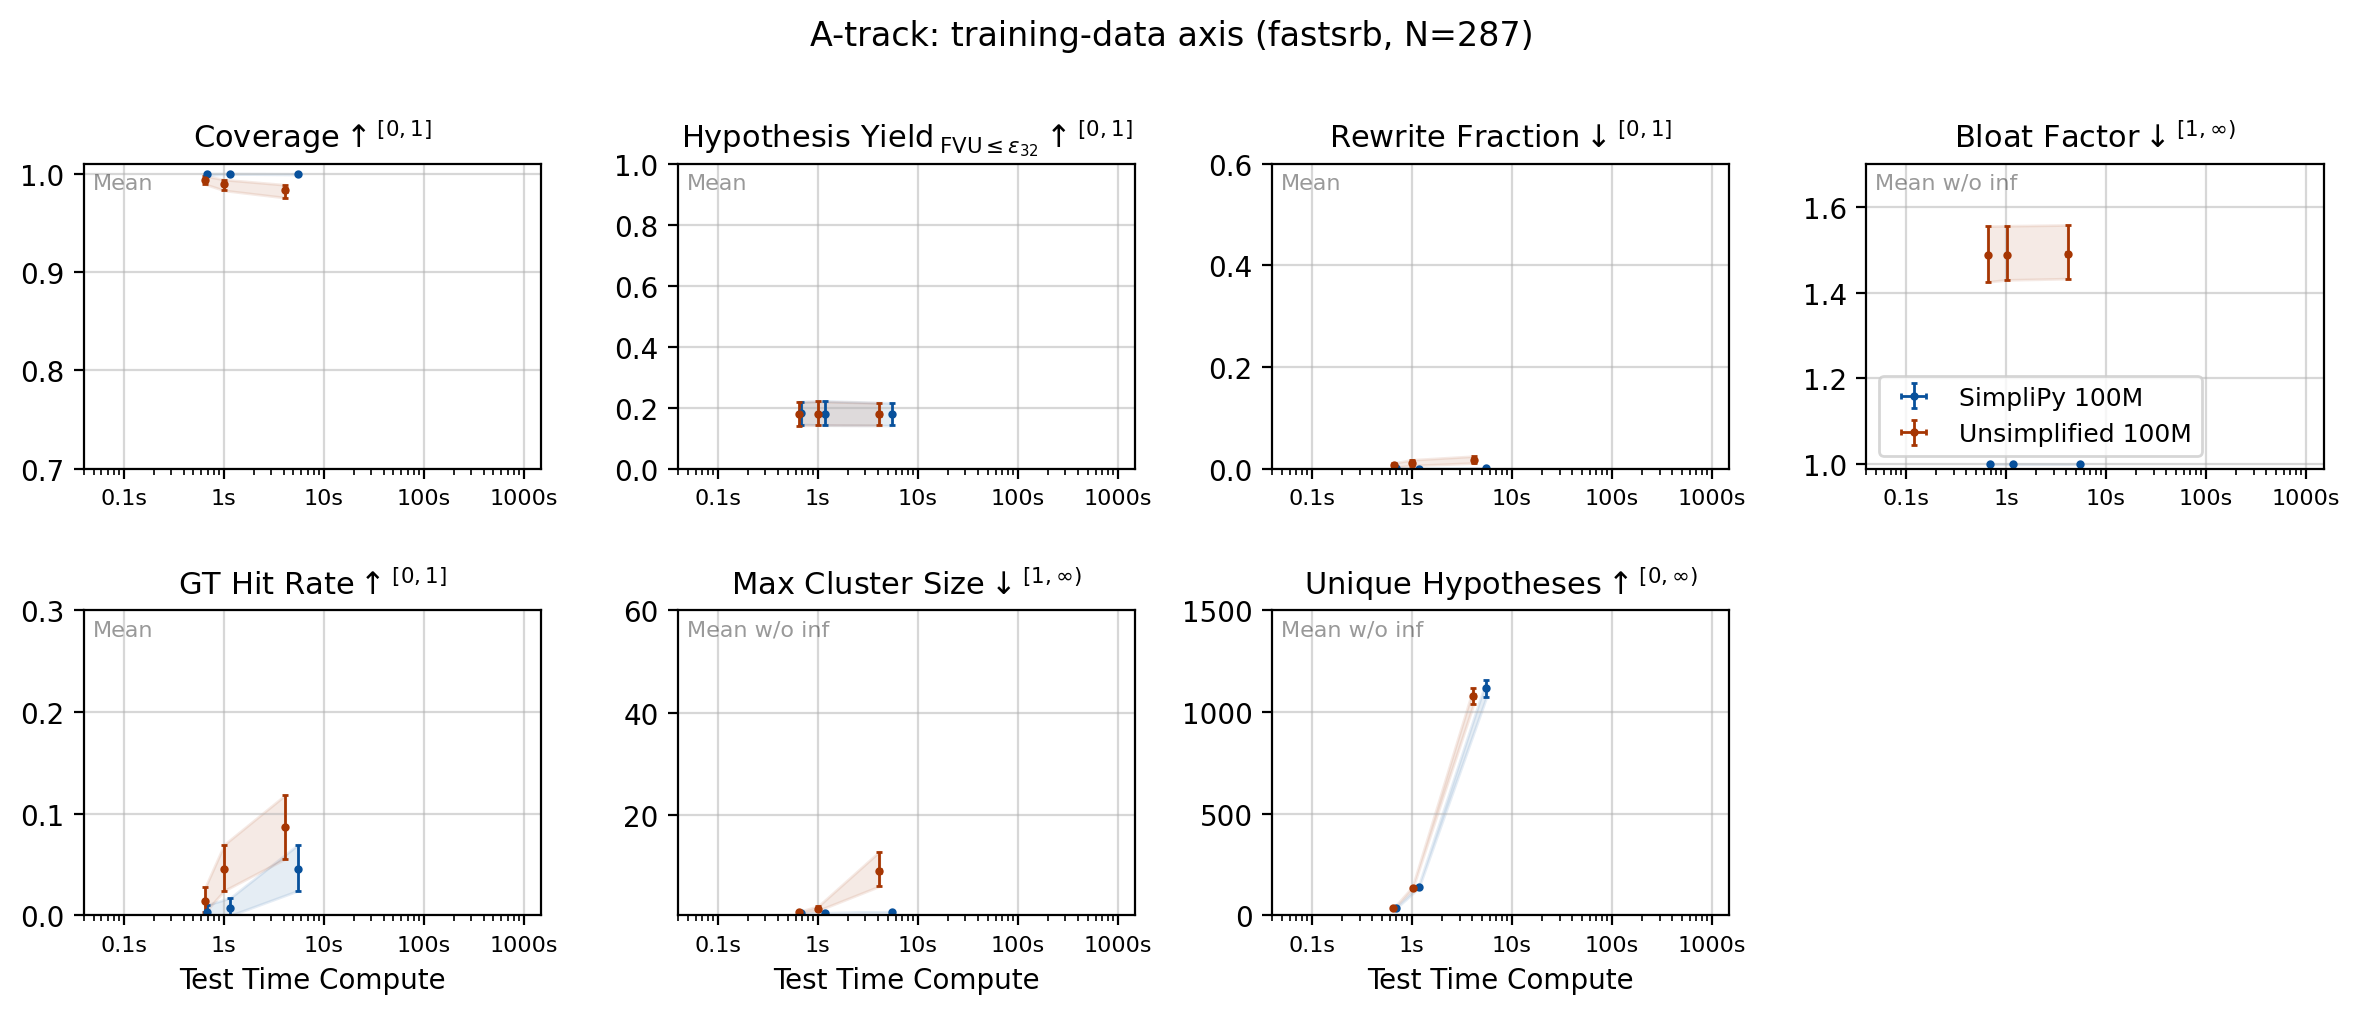

In [17]:
a_track = [
    ('v23.0-20M-A-S100', 'choices', '#08519C', 'SimpliPy 100M'),
    ('v23.0-20M-A-U100', 'choices', '#A63603', 'Unsimplified 100M'),
]
plot_track(a_track, save_as='a_track_metrics_vs_compute.svg', title_suffix='A-track: training-data axis (fastsrb, N=287)')


## Z-track: Decoder axis

Same 120M baseline checkpoint, two decoders. Softmax sampling samples
independently from the model's autoregressive distribution; beam search keeps
the top-K by joint log-probability. Choices/beam_width points: 64, 256, 2048
(beam at 256, 2048 still on Solomon's queue).


Saved /home/psaegert/Projects/flash-ansr/results/figures/system_effect/z_track_metrics_vs_compute.svg


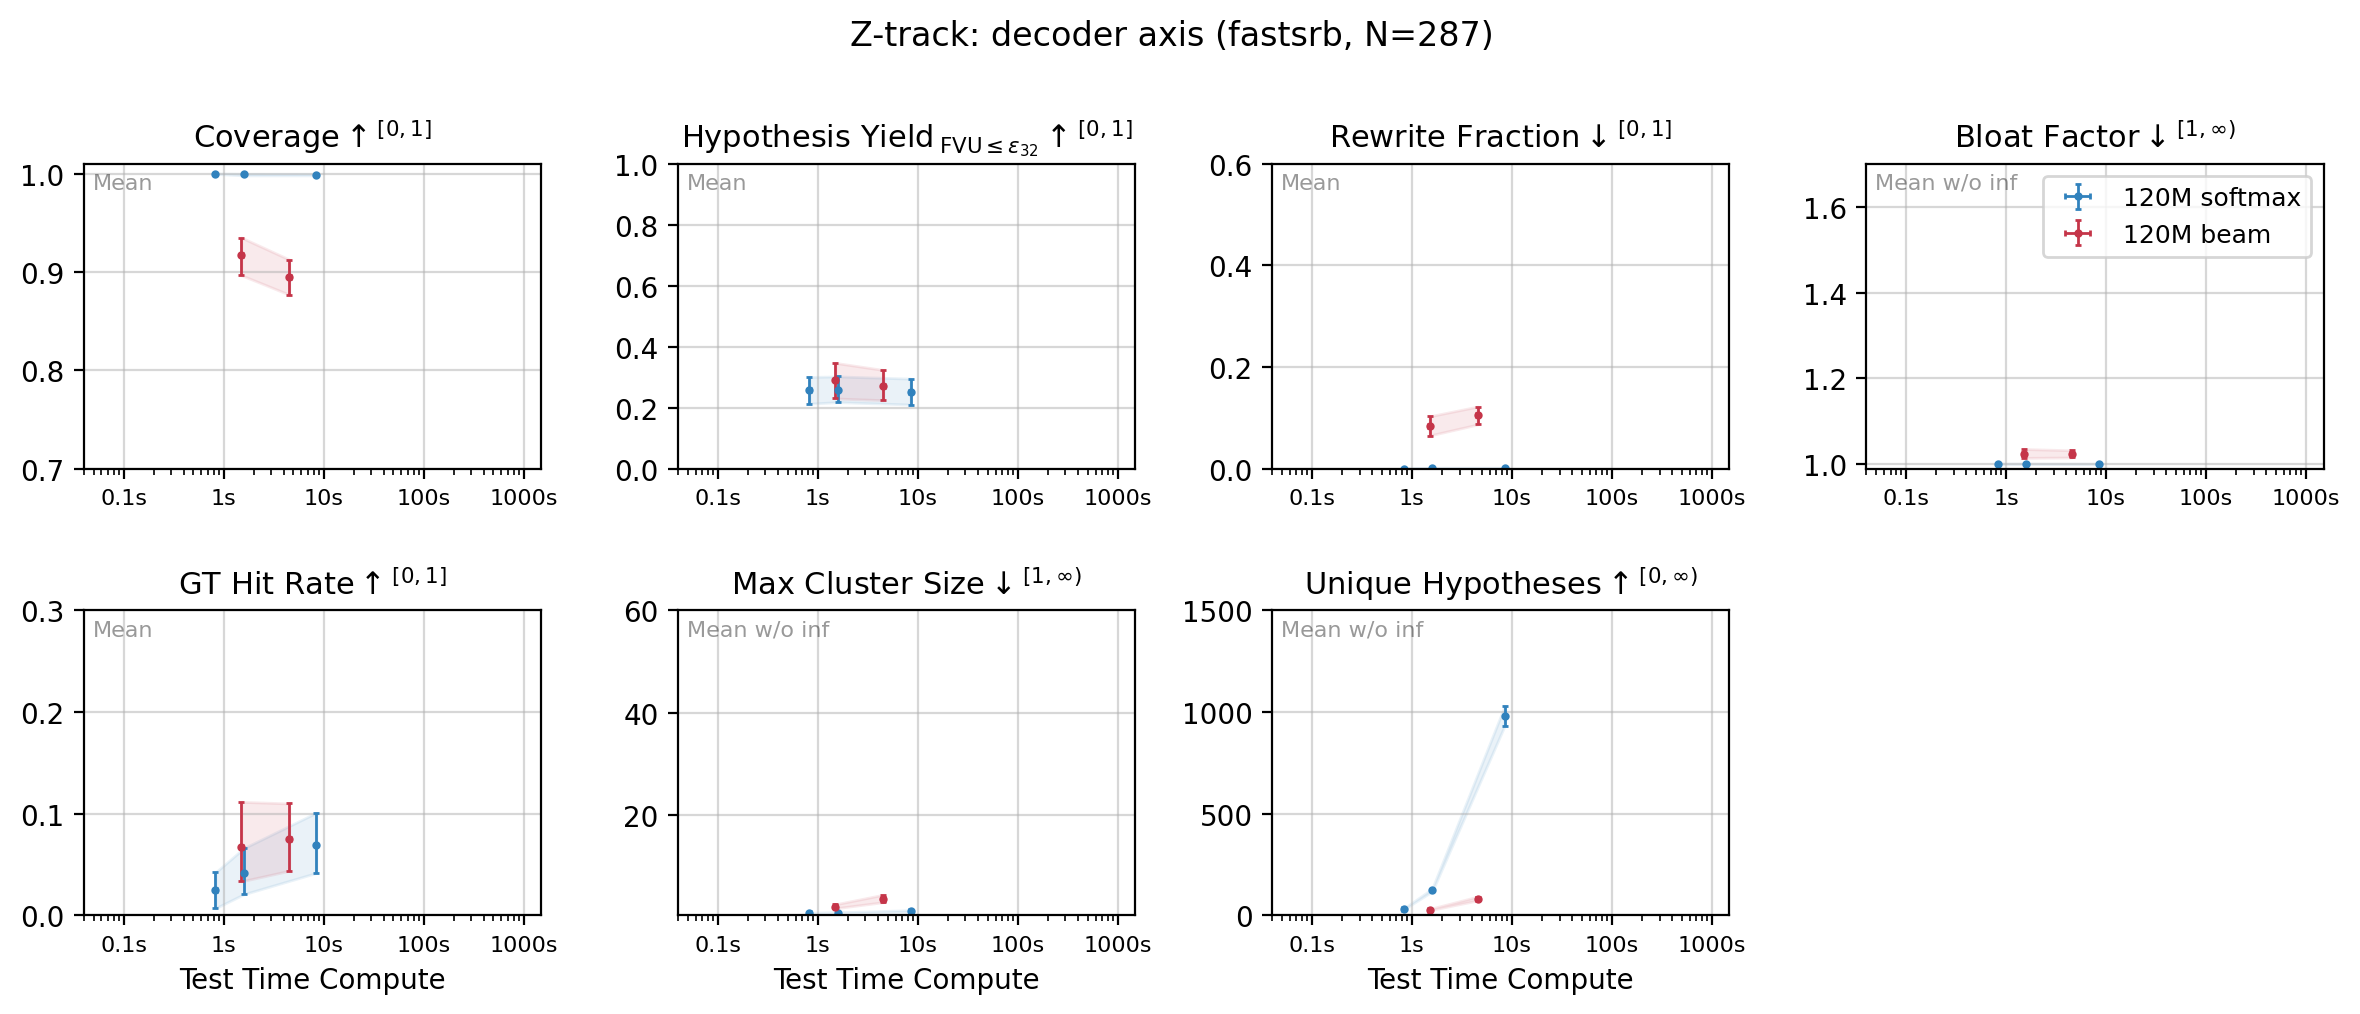

In [18]:
z_track = [
    ('v23.0-120M-softmax', 'choices',    '#3182BD', '120M softmax'),
    ('v23.0-120M-beam',    'beam_width', '#c53549', '120M beam'),
]
plot_track(z_track, save_as='z_track_metrics_vs_compute.svg', title_suffix='Z-track: decoder axis (fastsrb, N=287)')


## Cross-axis snapshot at matched compute (~3s fit_time)

Direct comparison of the four configurations on a single panel grid: this
exposes the cross-axis story — *training without simplification* (U100) and
*beam decoding* (120M-beam) shift different fingerprint axes, with both
ending up at elevated concentration but for distinct reasons.


Saved /home/psaegert/Projects/flash-ansr/results/figures/system_effect/cross_axis_metrics_vs_compute.svg


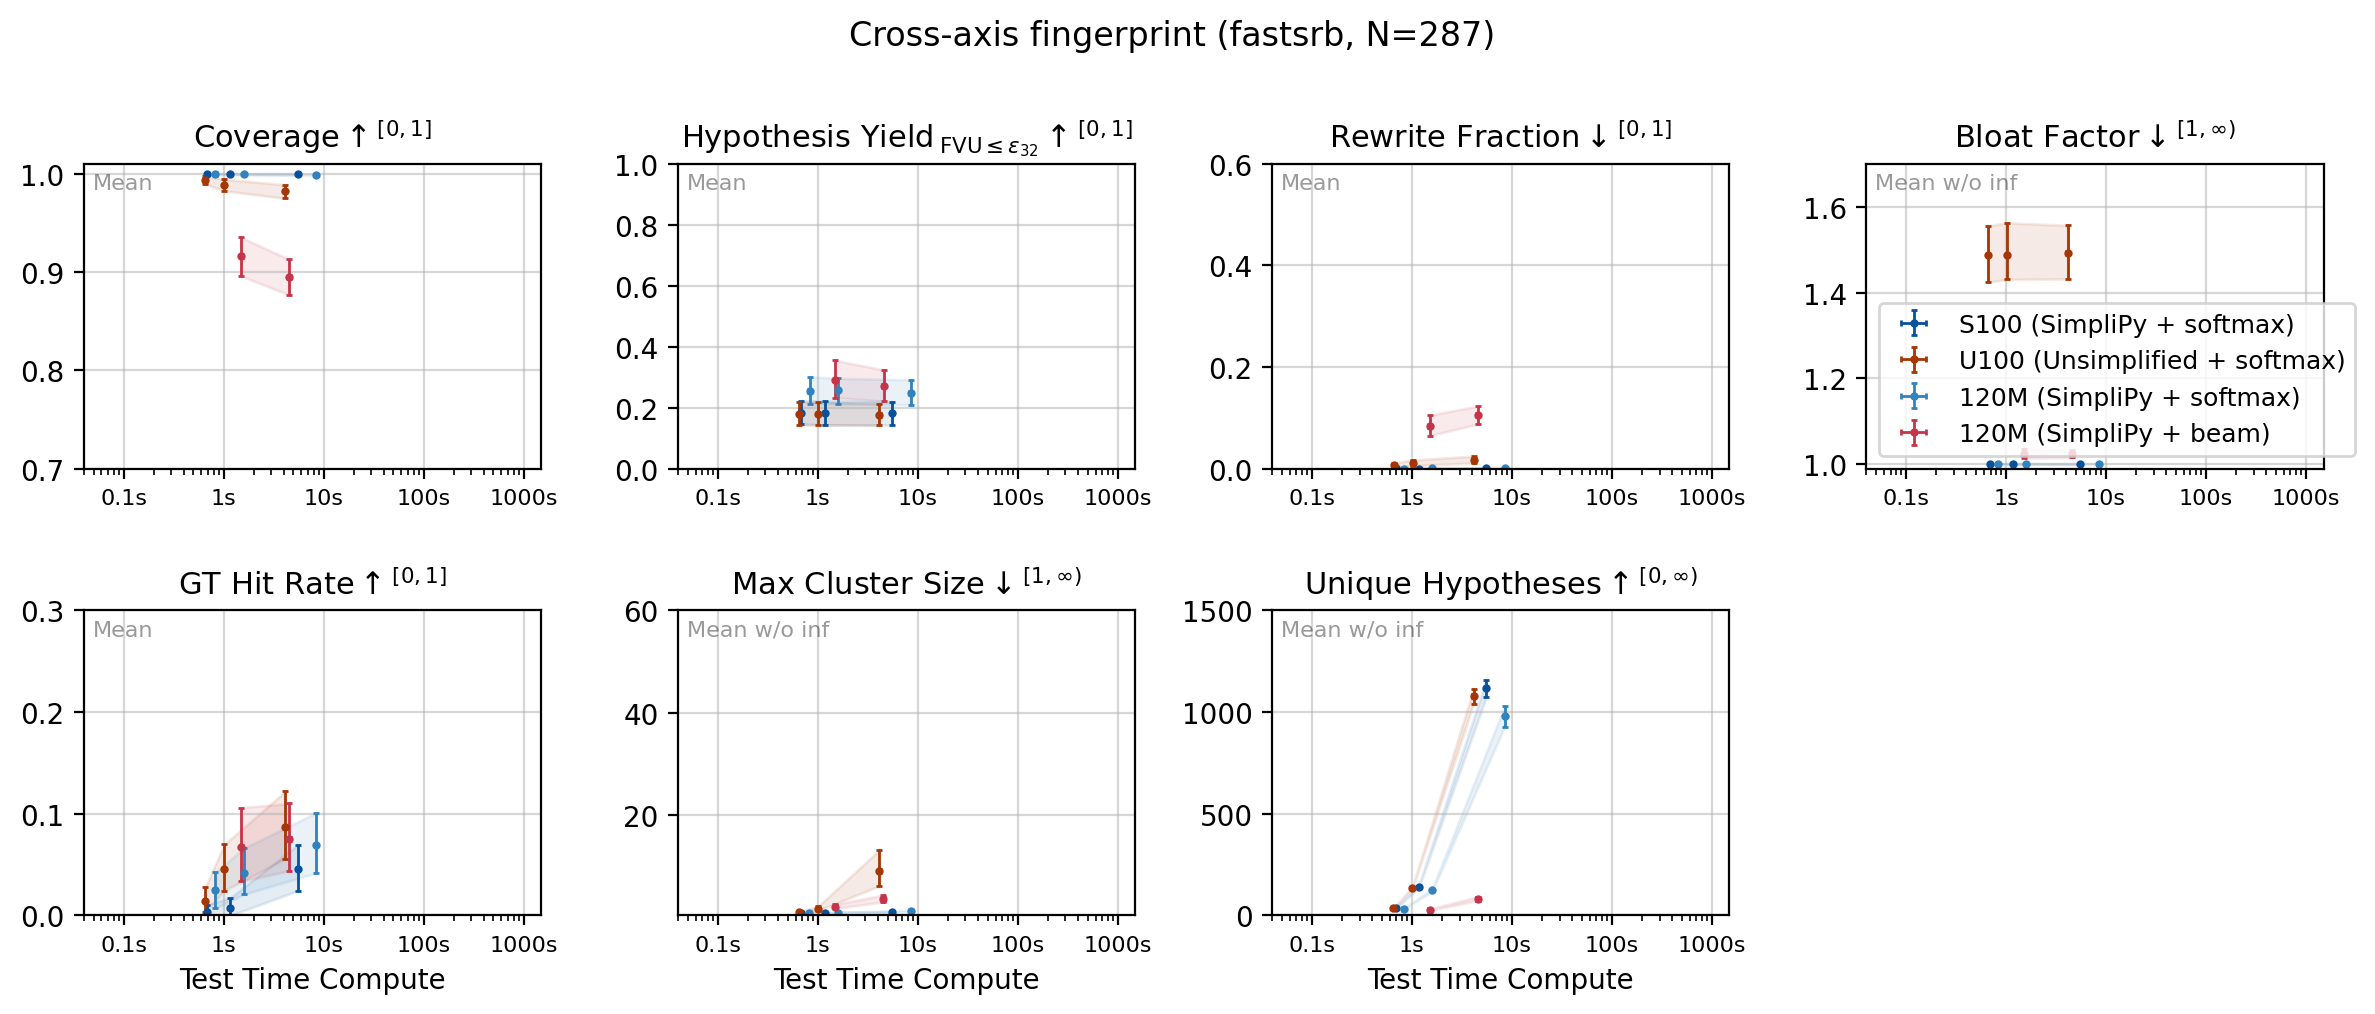

In [19]:
cross_axis = [
    ('v23.0-20M-A-S100',  'choices',    '#08519C', 'S100 (SimpliPy + softmax)'),
    ('v23.0-20M-A-U100',  'choices',    '#A63603', 'U100 (Unsimplified + softmax)'),
    ('v23.0-120M-softmax','choices',    '#3182BD', '120M (SimpliPy + softmax)'),
    ('v23.0-120M-beam',   'beam_width', '#c53549', '120M (SimpliPy + beam)'),
]
plot_track(cross_axis, save_as='cross_axis_metrics_vs_compute.svg', title_suffix='Cross-axis fingerprint (fastsrb, N=287)')


## Main-text summary table at the ~10s inference-time anchor

A single anchor compute point per row (chosen so each configuration's mean inference time per problem is roughly 10 s, matching the consistency target of the standard test-time-compute scaling evaluation in App.~\ref{app:detailed_test_time_scaling}). All four fingerprint axes plus mean fit time per sample, designed for inclusion in the camera-ready main text instead of multi-panel scaling figures (kept above for App N / sensitivity studies).

Format: `mean [95% CI lower, upper]` from a 1k-resample bootstrap. Configurations not yet probed at their target anchor (e.g. beam decoding at the larger c, while Solomon's queue is still running) appear with a `(pending)` marker; the table regenerates from `results` so it auto-updates once the dump lands.


In [20]:
import pandas as pd
from IPython.display import display, Markdown

# Per-row anchor (chosen so each config hits ~10s mean inference time per problem):
#   20M models reach 10s at c=4096 (extrapolated from c=2048 ~5s)
#   120M models already hit ~10s at c=2048
table_configs = [
    # (display_label, model_key, anchor_choices)
    ('SimpliPy 100M (softmax)',        'v23.0-20M-A-S100',   4096),
    ('Unsimplified 100M (softmax)',    'v23.0-20M-A-U100',   4096),
    ('120M baseline (softmax)',        'v23.0-120M-softmax', 2048),
    ('120M baseline (beam)',           'v23.0-120M-beam',    2048),
]

# Columns: (data_key, header_label, statistic, fmt). Time first, then 4 fingerprint axes.
table_metrics = [
    ('fit_time',      'Time (s)',         naninfmean, '{:.2f}'),
    ('coverage',      'Coverage',         np.nanmean, '{:.3f}'),
    ('quality',       'Yield',            np.nanmean, '{:.3f}'),
    ('concentration', 'Rewrite Frac.',    np.nanmean, '{:.3f}'),
    ('surface_form',  'Bloat Factor',     naninfmean, '{:.3f}'),
]

def _ci_str(rec, key, stat, fmt):
    if key not in rec or len(rec[key]) == 0:
        return '—'
    m, lo, hi = bootstrapped_metric_ci(rec[key], stat, n=1e3, interval=0.95)
    return f'{fmt.format(m)} [{fmt.format(lo)}, {fmt.format(hi)}]'

rows = []
for label, model_key, anchor_c in table_configs:
    cs = results.get(model_key, {}).get('results', {}).get(TEST_SET, {})
    if anchor_c not in cs:
        rows.append({'Configuration': f'{label} — (pending c={anchor_c})',
                     **{h: '—' for _, h, *_ in table_metrics}})
        continue
    rec = cs[anchor_c]
    row = {'Configuration': label}
    for metric, header, stat, fmt in table_metrics:
        row[header] = _ci_str(rec, metric, stat, fmt)
    rows.append(row)

df = pd.DataFrame(rows)

# Plain-text view in the notebook
print(df.to_string(index=False))

# Render as Markdown for inline display, and emit a LaTeX (booktabs) version for the paper.
display(Markdown(df.to_markdown(index=False)))

print('\n--- LaTeX (booktabs, paste into paper) ---\n')
print(df.to_latex(
    index=False,
    escape=False,
    column_format='l' + 'r' * (len(df.columns) - 1),
    caption=('Hypothesis-space coverage fingerprint at the ~10s inference-time anchor '
             '(c = 4096 for the 20M models; c = 2048 for the 120M models). '
             'Per-cell entries report mean and 95\\% bootstrap CI on fastsrb (N $\\approx$ 287; beam decoding occasionally returns no valid candidates).'),
    label='tab:fingerprint_main',
))


                   Configuration          Time (s)             Coverage                Yield        Rewrite Frac.         Bloat Factor          GT Hit Rate
         SimpliPy 100M (softmax) 5.56 [5.43, 5.68] 0.999 [0.999, 1.000] 0.180 [0.143, 0.220] 0.001 [0.000, 0.001] 1.001 [1.001, 1.001] 0.045 [0.024, 0.070]
     Unsimplified 100M (softmax) 4.13 [4.02, 4.25] 0.982 [0.975, 0.988] 0.177 [0.141, 0.216] 0.018 [0.012, 0.025] 1.491 [1.430, 1.564] 0.087 [0.056, 0.118]
         120M baseline (softmax) 8.47 [8.27, 8.70] 0.999 [0.998, 0.999] 0.250 [0.209, 0.292] 0.001 [0.001, 0.002] 1.001 [1.001, 1.002] 0.070 [0.045, 0.098]
120M baseline (beam) — (pending)                 —                    —                    —                    —                    —                    —


| Configuration                    | Time (s)          | Coverage             | Yield                | Rewrite Frac.        | Bloat Factor         | GT Hit Rate          |
|:---------------------------------|:------------------|:---------------------|:---------------------|:---------------------|:---------------------|:---------------------|
| SimpliPy 100M (softmax)          | 5.56 [5.43, 5.68] | 0.999 [0.999, 1.000] | 0.180 [0.143, 0.220] | 0.001 [0.000, 0.001] | 1.001 [1.001, 1.001] | 0.045 [0.024, 0.070] |
| Unsimplified 100M (softmax)      | 4.13 [4.02, 4.25] | 0.982 [0.975, 0.988] | 0.177 [0.141, 0.216] | 0.018 [0.012, 0.025] | 1.491 [1.430, 1.564] | 0.087 [0.056, 0.118] |
| 120M baseline (softmax)          | 8.47 [8.27, 8.70] | 0.999 [0.998, 0.999] | 0.250 [0.209, 0.292] | 0.001 [0.001, 0.002] | 1.001 [1.001, 1.002] | 0.070 [0.045, 0.098] |
| 120M baseline (beam) — (pending) | —                 | —                    | —                    | —                    | —                    | —                    |


--- LaTeX (booktabs, paste into paper) ---

\begin{table}
\caption{Hypothesis-space coverage fingerprint at $c = 2048$ candidates per problem. Per-cell entries report mean and 95\% bootstrap CI on fastsrb (N = 287 except where probes returned empty for some samples).}
\label{tab:fingerprint_c2048}
\begin{tabular}{lrrrrrr}
\toprule
Configuration & Time (s) & Coverage & Yield & Rewrite Frac. & Bloat Factor & GT Hit Rate \\
\midrule
SimpliPy 100M (softmax) & 5.56 [5.43, 5.68] & 0.999 [0.999, 1.000] & 0.180 [0.143, 0.220] & 0.001 [0.000, 0.001] & 1.001 [1.001, 1.001] & 0.045 [0.024, 0.070] \\
Unsimplified 100M (softmax) & 4.13 [4.02, 4.25] & 0.982 [0.975, 0.988] & 0.177 [0.141, 0.216] & 0.018 [0.012, 0.025] & 1.491 [1.430, 1.564] & 0.087 [0.056, 0.118] \\
120M baseline (softmax) & 8.47 [8.27, 8.70] & 0.999 [0.998, 0.999] & 0.250 [0.209, 0.292] & 0.001 [0.001, 0.002] & 1.001 [1.001, 1.002] & 0.070 [0.045, 0.098] \\
120M baseline (beam) — (pending) & — & — & — & — & — & — \\
\bottomrule
\en

---

To extend: add Y10 (SymPy at 10M) and B-track (architecture variants) probes
when their dumps land in `results/system_effect/`. The `PROBES` list at the
top is the only place that needs editing; the rest of the notebook adapts
automatically via the per-track plotting helper.


The B track ablations should be evaluated with the main evaluation suite. We can add the Y10 and S10 though to have a comparison between simplipy and sympy.